# Proyecto Integrador — Parte I: EDA + KDD con Apache Spark

**Dataset:** Contrataciones públicas del Perú **2023, 2024 y 2025**, estándar OCDS
(un JSON por mes, en `data/2023/`, `data/2024/`, `data/2025/`).
**Fuente:** Contrataciones Abiertas OCDS — OECE/OSCE, <https://contratacionesabiertas.osce.gob.pe/> ·
descarga masiva: <https://data.open-contracting.org/es/publication/135>

## Cómo ejecutar (en cualquier máquina con Docker)

Estos comandos se corren **en la terminal de tu computadora**, no dentro de este notebook
(este notebook ya vive dentro de un contenedor, así que no puede lanzar Docker por sí mismo).

> **¿Prefieres no usar la terminal?** Abre `00_Levantar_Docker.ipynb` en tu máquina (Jupyter o VS Code) y
> ejecútalo: hace exactamente estos mismos pasos desde celdas, verifica que el cluster esté sano e incluso
> puede ejecutar este notebook completo por ti.

```bash
# 1. clonar y entrar al proyecto
git clone https://github.com/paolovasquezg/dm-proj1.git && cd dm-proj1

# 2. levantar el cluster: Spark master + worker + Jupyter (una sola imagen para los tres)
#    la primera vez descarga la imagen (~2 GB); no hay build
docker compose up -d

# 3. ver que los 3 contenedores estén arriba
docker compose ps

# 4. abrir http://localhost:8888  ->  Parte1_EDA_KDD.ipynb  ->  Run All
#    UI del master: http://localhost:8080   ·   job en curso: http://localhost:4040

# 5. si algo falla, ver los logs
docker compose logs -f spark-worker

# 6. al terminar
docker compose down
```

Ajustes según la máquina (opcionales):

```bash
HOST_UID=$(id -u) docker compose up -d           # Linux con UID distinto de 1000
SPARK_WORKER_CORES=1 docker compose up -d        # si aparece OutOfMemory al leer los JSON
SPARK_WORKER_MEMORY=10g SPARK_EXECUTOR_MEMORY=8g docker compose up -d   # máquina con más RAM
```

**Orden del notebook:** primero el **EDA** (¿la data sirve?), luego se definen **qué se busca con cada técnica**,
y al final el **KDD** (se transforma la data a lo que realmente usaremos y se guarda en Parquet).

| # | Sección |
|---|---|
| 0 | Conexión a Spark y verificación del cluster |
| 1 | Carga del JSON (sin limpiar) |
| 2 | EDA |
| 3 | Preguntas de interés y técnicas |
| 4 | KDD: selección → limpieza → transformación → Parquet final |

## 0. Conexión a Spark y verificación del cluster

In [1]:
import os, socket, subprocess, sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F
from pyspark.sql.types import ArrayType, StructType
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80)

ROOT        = Path.cwd()
DATA_DIR    = ROOT / "data"                 # JSON crudos
PARQUET_DIR = ROOT / "parquet"              # staging + dataset final
FIG_DIR     = ROOT / "outputs" / "parte1"   # figuras del EDA
FIG_DIR.mkdir(parents=True, exist_ok=True)

# En Docker SPARK_MASTER=spark://spark-master:7077 (cluster).
# Fuera de Docker cae a local[*] para que el notebook corra igual.
SPARK_MASTER = os.environ.get("SPARK_MASTER", "local[*]")

builder = (SparkSession.builder
           .appName("P1-EDA-KDD-OCDS")
           .master(SPARK_MASTER)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))
if SPARK_MASTER.startswith("spark://"):
    # Los executors (contenedor worker) deben poder volver a conectarse al driver (este contenedor).
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} | master = {spark.sparkContext.master} | "
      f"paralelismo = {spark.sparkContext.defaultParallelism}")

ANIOS = [int(a) for a in os.environ.get("ANIOS", "2023,2024,2025").split(",")]
print("Años a procesar:", ANIOS)

def guardar_fig(nombre):
    plt.tight_layout(); plt.savefig(FIG_DIR / f"{nombre}.png", dpi=120); plt.show()

Spark 3.5.0 | master = spark://spark-master:7077 | paralelismo = 2
Años a procesar: [2023, 2024, 2025]


In [2]:
# Verificación del entorno: confirma que el notebook habla con el cluster y no con un Spark suelto.
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()          # 1 entrada por driver/executor vivo
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")
if not sc.master.startswith("spark://"):
    print("\nAVISO: estás en modo local (sin cluster). Con Docker deberías ver spark://spark-master:7077.")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


## 1. Carga de los datos crudos

Los archivos están en `data/2023/`, `data/2024/` y `data/2025/` (un JSON por mes).
Cada archivo es **un solo objeto JSON multilínea** (paquete OCDS), por eso se lee con `multiLine=true`.
Un JSON multilínea no se puede dividir: cada archivo es una tarea de Spark. Por eso, tras leerlo **una vez**,
se guarda una copia plana en Parquet (*staging*, sin limpiar) y el EDA trabaja sobre ella.

In [3]:
# Estructura esperada: data/<anio>/<mes>.json  (también acepta data/*.json plano)
archivos = []
for a in ANIOS:
    archivos += sorted((DATA_DIR / str(a)).glob("*.json"), key=lambda p: (len(p.stem), p.stem))
if not archivos:
    archivos = sorted(DATA_DIR.glob("*.json"), key=lambda p: (len(p.stem), p.stem))
assert archivos, f"No hay JSON en {DATA_DIR}. Esperado: data/2023/1.json, data/2024/1.json, ..."

MB_JSON = sum(a.stat().st_size for a in archivos) / 1024**2
print(f"{len(archivos)} archivos | {MB_JSON:,.1f} MB")
for a in ANIOS:
    fs = list((DATA_DIR / str(a)).glob("*.json"))
    if fs:
        print(f"  {a}: {len(fs)} archivos, {sum(f.stat().st_size for f in fs)/1024**2:,.0f} MB")

raw = spark.read.option("multiLine", "true").option("mode", "PERMISSIVE").json([str(a) for a in archivos])
top = {c.lower() for c in raw.columns}

# El envoltorio OCDS puede venir de 3 formas: se detecta en vez de asumirlo.
if "releases" in top:
    rel = raw.select(F.explode("releases").alias("r")).select("r.*")
elif "records" in top:
    rec = raw.select(F.explode("records").alias("x"))
    rel = (rec.select("x.compiledRelease.*") if "compiledRelease" in rec.select("x.*").columns
           else rec.select(F.explode("x.releases").alias("r")).select("r.*"))
else:
    rel = raw
print("Campos de primer nivel de un proceso:", rel.columns)

36 archivos | 3,859.9 MB
  2023: 12 archivos, 1,065 MB
  2024: 12 archivos, 1,394 MB
  2025: 12 archivos, 1,401 MB
Campos de primer nivel de un proceso: ['awards', 'buyer', 'contracts', 'dataSegmentation', 'date', 'id', 'initiationType', 'ocid', 'parties', 'planning', 'publishedDate', 'sources', 'tag', 'tender']


In [4]:
# --- utilidades: los campos OCDS son opcionales, se accede de forma segura ---
def rutas(schema, pre=""):
    out = []
    for f in schema.fields:
        out.append(pre + f.name)
        t = f.dataType.elementType if isinstance(f.dataType, ArrayType) else f.dataType
        if isinstance(t, StructType):
            out += rutas(t, pre + f.name + ".")
    return out
RUTAS = {r.lower() for r in rutas(rel.schema)}
existe = lambda p: p.lower() in RUTAS

def col(p, tipo="string"):
    return F.col(p).cast(tipo) if existe(p) else F.lit(None).cast(tipo)

def fecha(c):   # '2025-03-14T09:15:00-05:00' -> timestamp
    return F.to_timestamp(F.substring(c.cast("string"), 1, 19), "yyyy-MM-dd'T'HH:mm:ss")

# Vista plana mínima: SOLO se aplana, no se limpia nada (eso es trabajo del KDD).
base = rel.select(
    col("ocid").alias("ocid"),
    # Fecha del proceso: inicio de convocatoria -> fecha de adjudicación -> fecha del release
    F.coalesce(fecha(col("tender.tenderPeriod.startDate")),
               fecha(F.element_at(col("awards.date", "array<string>"), 1)),
               fecha(col("date"))).alias("fecha"),
    F.coalesce(col("tender.procuringEntity.name"), col("buyer.name")).alias("entidad"),
    F.input_file_name().alias("_archivo"),
    (F.expr("element_at(filter(transform(parties, p -> CASE WHEN array_contains(p.roles,'buyer') "
            "THEN p.address.region END), x -> x IS NOT NULL), 1)")
     if existe("parties.address.region") else F.lit(None).cast("string")).alias("region"),
    col("tender.title").alias("codigo_proceso"),
    col("tender.description").alias("descripcion"),
    F.concat_ws(" ", col("tender.items.description", "array<string>")).alias("items_desc"),
    col("tender.status").alias("estado"),
    col("tender.procurementMethod").alias("metodo"),
    col("tender.procurementMethodDetails").alias("metodo_detalle"),
    col("tender.mainProcurementCategory").alias("categoria"),
    col("tender.value.amount", "double").alias("monto_referencial"),
    col("tender.value.currency").alias("moneda"),
    col("tender.numberOfTenderers", "int").alias("n_postores"),
    (F.expr("aggregate(filter(awards.value.amount, x -> x IS NOT NULL), CAST(NULL AS DOUBLE), "
            "(acc, x) -> coalesce(acc, 0D) + x)")
     if existe("awards.value.amount") else F.lit(None).cast("double")).alias("monto_adjudicado"),
    (F.expr("element_at(filter(transform(awards, a -> element_at(a.suppliers.name, 1)), x -> x IS NOT NULL), 1)")
     if existe("awards.suppliers.name") else F.lit(None).cast("string")).alias("proveedor"),
    (F.expr("array_distinct(filter(flatten(transform(coalesce(tender.items, array()), "
            "i -> transform(filter(coalesce(i.additionalClassifications, array()), "
            "c -> upper(c.scheme) = 'UNSPSC'), c -> c.id))), x -> x IS NOT NULL))")
     if existe("tender.items.additionalClassifications.id") else F.array().cast("array<string>")).alias("unspsc"),
)

# El año del proceso sale de la fecha; si faltara, del nombre de la carpeta (data/<anio>/).
base = (base
        .withColumn("anio_carpeta", F.regexp_extract("_archivo", r"/(\d{4})/[^/]+\.json$", 1).cast("int"))
        .withColumn("anio", F.coalesce(F.year("fecha"), F.col("anio_carpeta")))
        .drop("_archivo", "anio_carpeta"))

base.write.mode("overwrite").parquet(str(PARQUET_DIR / "staging"))
base = spark.read.parquet(str(PARQUET_DIR / "staging")).cache()
N = base.count()
print(f"Staging listo: {N:,} filas x {len(base.columns)} columnas")

Staging listo: 236,229 filas x 18 columnas


---
## 2. EDA — ¿la data es apta?

Todo se calcula en Spark; al driver sólo baja el resultado agregado (pocas filas) para graficar.

### 2.1 Volumen y esquema

In [5]:
n_ocid = base.select("ocid").distinct().count()
mb_pq = sum(f.stat().st_size for f in (PARQUET_DIR / "staging").rglob("*.parquet")) / 1024**2
print(f"Procesos (filas): {N:,} | ocid únicos: {n_ocid:,} | repetidos: {N - n_ocid:,}")
print(f"Tamaño: JSON {MB_JSON:,.0f} MB  ->  Parquet {mb_pq:,.1f} MB")
base.groupBy("anio").count().orderBy("anio").show()
base.printSchema()

Procesos (filas): 236,229 | ocid únicos: 236,229 | repetidos: 0
Tamaño: JSON 3,860 MB  ->  Parquet 53.0 MB
+----+-----+
|anio|count|
+----+-----+
|2023|76390|
|2024|80263|
|2025|79301|
|2026|  275|
+----+-----+

root
 |-- ocid: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- codigo_proceso: string (nullable = true)
 |-- descripcion: string (nullable = true)
 |-- items_desc: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- metodo: string (nullable = true)
 |-- metodo_detalle: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- monto_referencial: double (nullable = true)
 |-- moneda: string (nullable = true)
 |-- n_postores: integer (nullable = true)
 |-- monto_adjudicado: double (nullable = true)
 |-- proveedor: string (nullable = true)
 |-- unspsc: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- anio: integer (nullable = t

**Lectura.** Tres años de JSON anidado (referencia: 2025 solo ya pesa ~1.4 GB y trae ~79 mil procesos, así que
los tres rondan los 4 GB y ~240 mil procesos). El volumen en filas es manejable, pero el costo real está en
parsear JSON anidado y, sobre todo, en las comparaciones por pares de las Partes II–III: con ~240 mil procesos
son ~29 mil millones de pares, inviable sin Spark ni LSH. El paso a Parquet reduce el tamaño decenas de veces.

Los `ocid` repetidos aparecen porque un proceso que empezó un año y se adjudicó al siguiente puede publicarse
en dos archivos: el KDD se queda con la versión más reciente.

### 2.2 Valores nulos

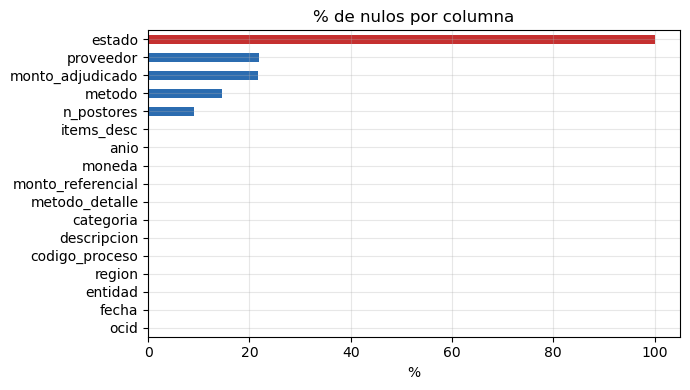

In [6]:
cols_simples = [c for c, t in base.dtypes if not t.startswith("array")]
nulos = (base.select([
            (100 * F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), 1)) / N).alias(c)
            for c in cols_simples])
         .toPandas().T[0].sort_values())

nulos.plot.barh(figsize=(7, 4), color=["#c53030" if v > 50 else "#2b6cb0" for v in nulos])
plt.title("% de nulos por columna"); plt.xlabel("%")
guardar_fig("01_nulos")

**Lectura.** Los campos clave (`ocid`, `fecha`, `entidad`, `descripcion`, `monto_referencial`) están completos.
`estado` viene vacío y `metodo` está muy incompleto → se descartan en el KDD (`metodo_detalle` lo reemplaza).
Los nulos de `monto_adjudicado`/`proveedor` **no son errores**: son procesos aún no adjudicados o desiertos,
así que no se imputan.

### 2.3 Distribución temporal

+-------------------+-------------------+
|                min|                max|
+-------------------+-------------------+
|2023-01-01 00:00:00|2026-09-13 12:05:36|
+-------------------+-------------------+



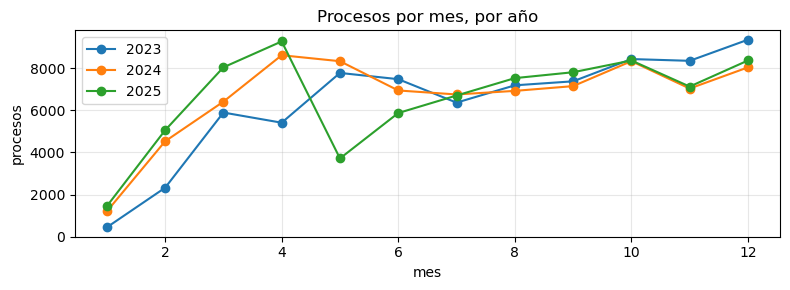

In [7]:
base.select(F.min("fecha").alias("min"), F.max("fecha").alias("max")).show()

serie = (base.where(F.col("anio").isin(ANIOS))
         .groupBy("anio", F.month("fecha").alias("mes")).count()
         .orderBy("anio", "mes").toPandas())

plt.figure(figsize=(8, 3))
for a, g in serie.groupby("anio"):
    plt.plot(g["mes"], g["count"], marker="o", label=a)
plt.title("Procesos por mes, por año"); plt.xlabel("mes"); plt.ylabel("procesos"); plt.legend()
guardar_fig("02_serie_mensual")

**Lectura.** Hay una dimensión temporal continua a lo largo de los tres años (con algunos registros fuera de
rango que se filtran en el KDD). Comparar las curvas año a año muestra la **estacionalidad** de la compra pública
(típicamente sube hacia fin de año). Además, tres años dan un flujo mucho más largo para la Parte IV: las
ventanas de DGIM y los sketches se vuelven interesantes recién con muchos eventos.

### 2.4 Comparación entre años

In [8]:
por_anio = (base.where(F.col("anio").isin(ANIOS)).groupBy("anio").agg(
        F.count("*").alias("procesos"),
        F.countDistinct("entidad").alias("entidades"),
        F.countDistinct("proveedor").alias("proveedores"),
        F.round(F.expr("percentile_approx(monto_referencial, 0.5)"), 0).alias("monto_mediano"),
        F.round(100 * F.avg((F.col("n_postores") == 1).cast("int")), 1).alias("%_postor_unico"))
      .orderBy("anio").toPandas())
por_anio

,anio,procesos,entidades,proveedores,monto_mediano,%_postor_unico
0,2023,76390,2633,28804,159656.0,13.6
1,2024,80263,2749,31293,166058.0,11.7
2,2025,79301,2822,31187,185624.0,11.6


**Lectura.** Tener tres años permite preguntas que con uno solo no se pueden hacer: si el % de procesos con
**un solo postor** sube o baja, si entran proveedores nuevos o se concentran los mismos, y si los montos
medianos se mueven. También da una línea base: un patrón que se repite los tres años es estructural, no un
hecho aislado de 2025.

### 2.5 Variables categóricas

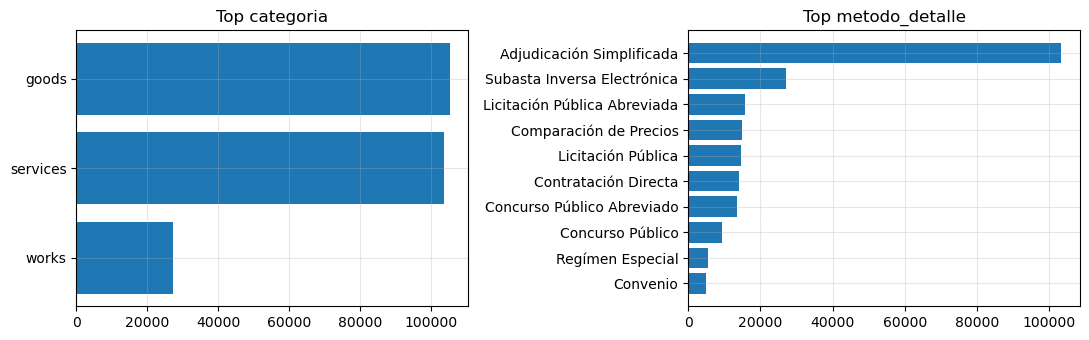

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for i, c in enumerate(["categoria", "metodo_detalle"]):
    d = base.groupBy(c).count().orderBy(F.desc("count")).limit(10).toPandas().iloc[::-1]
    ax[i].barh(d[c].astype(str).str[:35], d["count"]); ax[i].set_title(f"Top {c}")
guardar_fig("03_categoricas")

**Lectura.** Bienes y servicios dominan; obras son menos procesos pero de mayor monto. Pocos métodos
concentran la mayoría de procesos (Adjudicación Simplificada, Licitación/Concurso Abreviado, Subasta Inversa).
Los valores vienen con mayúsculas/tildes mixtas → se normalizan en el KDD.

### 2.6 Montos

Percentiles monto referencial (S/): {'p05': '47,538', 'p25': '85,983', 'p50': '186,000', 'p75': '492,887', 'p95': '4,349,816', 'p99': '1,134,909,484'}
+---------+-------------+
|monto_<=0|moneda_no_PEN|
+---------+-------------+
|    16203|         4797|
+---------+-------------+



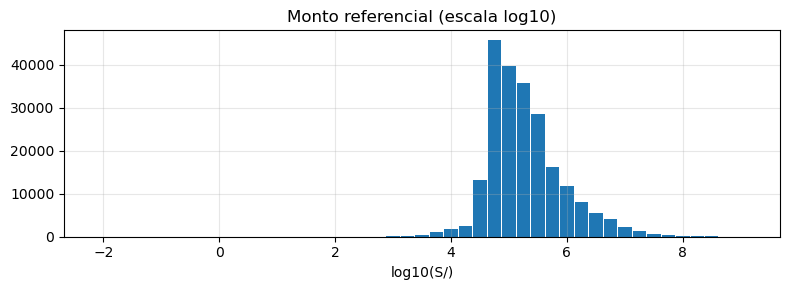

In [10]:
m = base.where(F.col("monto_referencial") > 0)
q = m.approxQuantile("monto_referencial", [.05, .25, .5, .75, .95, .99], 0.01)
print("Percentiles monto referencial (S/):", dict(zip(["p05","p25","p50","p75","p95","p99"], [f"{x:,.0f}" for x in q])))
base.select(
    F.sum((F.col("monto_referencial") <= 0).cast("int")).alias("monto_<=0"),
    F.sum((F.col("moneda") != "PEN").cast("int")).alias("moneda_no_PEN")).show()

hist = (m.groupBy((F.floor(F.log10("monto_referencial") * 4) / 4).alias("log10")).count()
        .orderBy("log10").toPandas())
plt.figure(figsize=(8, 3)); plt.bar(hist["log10"], hist["count"], width=.23)
plt.title("Monto referencial (escala log10)"); plt.xlabel("log10(S/)")
guardar_fig("04_montos")

**Lectura.** Distribución muy sesgada a la derecha (la media no sirve, se usa mediana y escala log). En log se ve
casi normal → se discretiza en **tramos de monto** para usarlos como ítems de canasta. Hay montos ≤ 0 y
monedas distintas de PEN (pocos) que el KDD trata.

### 2.7 Entidades y proveedores principales (Spark SQL)

,n_proveedores,pct_monto_top10
0,66141,5.241068


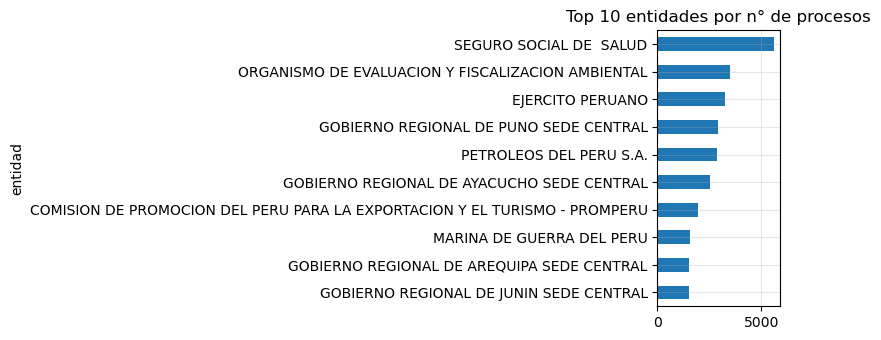

In [11]:
base.createOrReplaceTempView("procesos")
top_ent = spark.sql('''
    SELECT upper(trim(entidad)) AS entidad, COUNT(*) AS procesos
    FROM procesos GROUP BY 1 ORDER BY procesos DESC LIMIT 10''').toPandas()

conc = spark.sql('''
    WITH p AS (SELECT upper(trim(proveedor)) AS proveedor, SUM(monto_adjudicado) AS monto
               FROM procesos WHERE proveedor IS NOT NULL GROUP BY 1)
    SELECT COUNT(*) AS n_proveedores,
           SUM(CASE WHEN rk <= 10 THEN monto END) / SUM(monto) * 100 AS pct_monto_top10
    FROM (SELECT *, ROW_NUMBER() OVER (ORDER BY monto DESC) AS rk FROM p)''').toPandas()
display(conc)

top_ent.iloc[::-1].plot.barh(x="entidad", y="procesos", legend=False, figsize=(8, 3.5))
plt.title("Top 10 entidades por n° de procesos")
guardar_fig("05_top_entidades")

**Lectura.** Hay entidades y proveedores que se repiten mucho y un grupo pequeño de proveedores concentra una
parte importante del monto: son candidatos naturales a *heavy hitters* (Count-Min Sketch) y a buscar
proveedores/procesos parecidos (MinHash/LSH).

### 2.8 ¿Sirve el texto y los códigos para similitud?

In [12]:
txt = base.select(
    F.size(F.split(F.trim("descripcion"), r"\s+")).alias("palabras"),
    F.size("unspsc").alias("n_unspsc"))
print("Palabras por descripción (p25, p50, p75, p95):",
      txt.approxQuantile("palabras", [.25, .5, .75, .95], .01))
print("Descripciones distintas:", base.select("descripcion").distinct().count(), "de", N)
print("Códigos UNSPSC distintos:", base.select(F.explode("unspsc")).distinct().count())
txt.groupBy("n_unspsc").count().orderBy("n_unspsc").show(5)
base.select("descripcion").sample(fraction=min(1.0, 50 / N), seed=7).show(5, truncate=90)

Palabras por descripción (p25, p50, p75, p95): [18.0, 29.0, 40.0, 50.0]
Descripciones distintas: 190740 de 236229
Códigos UNSPSC distintos: 5175
+--------+------+
|n_unspsc| count|
+--------+------+
|       0| 36467|
|       1|193160|
|       2|  4666|
|       3|   808|
|       4|   312|
+--------+------+
only showing top 5 rows

+------------------------------------------------------------------------------------------+
|                                                                               descripcion|
+------------------------------------------------------------------------------------------+
|CONTRATACION DE SERVICI ODE CONSULTORIA DE PERITAJE TECNICO Y FINANCIERO DE OBRA DEL PR...|
|SERVICIO DE ARRENDAMIENTO DE INMUEBLES PARA LAS DIFERENTES DIRECCIONES ESPECIALIZADAS P...|
|ADQUISICION DE VESTUARIO PARA EL PERSONAL DE CAMPO QUE LABORA EN EL PLAN DE MANTENIMIEN...|
|Suministro de Bienes: Adquisición de Diesel B5 para la operatividad de las unidades móv...|
|        SERVICIO

**Lectura.** `descripcion` siempre existe y tiene decenas de palabras: es una buena base para **shingles** y
MinHash. En cambio, la mayoría de procesos tiene **un solo código UNSPSC** (o ninguno): como conjunto es
demasiado pobre para Jaccard (casi todo daría 0 o 1). Decisión: la similitud se hace sobre **texto**, y los
códigos se usan agregados (familia/segmento) como ítems de canasta.

### 2.9 Dictamen: ¿el dataset es apto?

In [13]:
en_rango = base.where(F.col("anio").isin(ANIOS)).count()
dictamen = pd.DataFrame([
    ("Volumen para Spark",        f"{MB_JSON:,.0f} MB JSON, {N:,} procesos ({len(ANIOS)} años), {N * (N - 1) / 2 / 1e6:,.0f} millones de pares posibles", "Sí"),
    ("Conjuntos / vectores",      f"descripción completa ({100 - nulos['descripcion']:.0f}%) -> shingles / TF-IDF", "Sí"),
    ("Dimensión temporal",        f"{100 * en_rango / N:.1f}% de procesos con fecha en {min(ANIOS)}-{max(ANIOS)}", "Sí"),
    ("Estructura transaccional",  "categoría, método, región, tramo de monto, competencia, rubro UNSPSC", "Sí"),
], columns=["criterio del enunciado", "evidencia del EDA", "cumple"])
dictamen

,criterio del enunciado,evidencia del EDA,cumple
0,Volumen para Spark,"3,860 MB JSON, 236,229 procesos (3 años), 27,902 millones de pares posibles",Sí
1,Conjuntos / vectores,descripción completa (100%) -> shingles / TF-IDF,Sí
2,Dimensión temporal,99.9% de procesos con fecha en 2023-2025,Sí
3,Estructura transaccional,"categoría, método, región, tramo de monto, competencia, rubro UNSPSC",Sí


---
## 3. Preguntas de interés y qué hallaremos con cada técnica

**P1 — Competencia.** ¿Qué combinaciones de método, monto, rubro y región se asocian a procesos con
**un solo postor**? (baja competencia = mayor riesgo de sobrecosto)

**P2 — Fraccionamiento / procesos repetidos.** ¿Hay procesos **casi idénticos** de una misma entidad, en fechas
cercanas y con montos bajos, que sugieran dividir una compra para evadir un método más exigente?

**P3 — Precios de referencia.** Para procesos con **objeto parecido**, ¿cuánto varía el monto contratado entre
entidades y regiones?

| Técnica | Qué vamos a hallar | Columna(s) del dataset final | Pregunta |
|---|---|---|---|
| **Jaccard + Shingling** | Similitud exacta entre descripciones en una muestra (línea base) | `shingles` | P2 |
| **MinHash** | Firma compacta que aproxima Jaccard sin guardar los conjuntos completos | `shingles` | P2 |
| **LSH** (MinHashLSH) | Pares de procesos casi duplicados **sin comparar todos contra todos**; luego se filtra misma entidad + fechas cercanas | `shingles`, `entidad`, `fecha` | P2 |
| **ANN: IVF / HNSW** | Los *k* procesos más parecidos a uno dado (TF-IDF) para comparar sus montos | `tokens`, `monto_final` | P3 |
| **Bloom Filter** | ¿Este par entidad–proveedor ya apareció antes en el flujo? (reincidencia) | `entidad`, `proveedor`, `fecha` | P2 |
| **Count-Min Sketch** | Proveedores y entidades más frecuentes (*heavy hitters*) sin tabla exacta | `proveedor`, `entidad` | P2 |
| **DGIM** | Cuántos procesos con postor único hubo en la ventana reciente del flujo | `postor_unico`, `fecha` | P1 |
| **Apriori / FP-Growth** | Reglas tipo `{CONTRATACIÓN DIRECTA, tramo alto} → {postor único}` | `canasta` | P1 |

---
## 4. KDD — transformar la data a lo que realmente usaremos

| Etapa | Qué se hace |
|---|---|
| **Selección** | Quedarse sólo con las columnas útiles para P1–P3 |
| **Preprocesamiento** | Normalizar texto, deduplicar, filtrar fechas y monedas, tratar montos inválidos |
| **Transformación** | Concatenar texto, tokens, shingles, tramos de monto, rubro UNSPSC y canasta |
| **Minería / Interpretación** | Partes II–V (este notebook deja la data lista) |

### 4.1 Selección

In [14]:
# Se descartan: columnas casi vacías (según el EDA) y las que no aportan a P1–P3.
descartar = sorted(set([c for c in cols_simples if nulos[c] > 95] + ["metodo", "codigo_proceso"]))
print("Descartadas:", descartar)
sel = base.drop(*descartar)
print("Seleccionadas:", sel.columns)

Descartadas: ['codigo_proceso', 'estado', 'metodo']
Seleccionadas: ['ocid', 'fecha', 'entidad', 'region', 'descripcion', 'items_desc', 'metodo_detalle', 'categoria', 'monto_referencial', 'moneda', 'n_postores', 'monto_adjudicado', 'proveedor', 'unspsc', 'anio']


### 4.2 Preprocesamiento (limpieza)

- **Texto** en mayúsculas y sin espacios extra (evita que “Municipalidad X” y “MUNICIPALIDAD X ” cuenten como dos).
- **Duplicados:** si un `ocid` aparece más de una vez se queda el registro más reciente.
- **Fechas:** sólo los años cargados (2023–2025); se descartan fechas fuera de rango o nulas.
- **Moneda:** sólo PEN (sumar soles con dólares no tiene sentido; son pocos procesos).
- **Montos ≤ 0:** se ponen en nulo (imposibles), pero el proceso se conserva para texto y frecuencias.

In [15]:
pasos = [("staging", sel.count())]

limpio = sel
for c in ["entidad", "region", "proveedor", "metodo_detalle", "categoria"]:
    limpio = limpio.withColumn(c, F.upper(F.trim(F.col(c))))

w = Window.partitionBy("ocid").orderBy(F.col("fecha").desc_nulls_last())
limpio = limpio.withColumn("_rn", F.row_number().over(w)).where("_rn = 1").drop("_rn")
pasos.append(("sin duplicados", limpio.count()))

limpio = limpio.where(F.col("anio").isin(ANIOS))
pasos.append((f"fecha en {min(ANIOS)}-{max(ANIOS)}", limpio.count()))

limpio = limpio.where(F.coalesce(F.col("moneda"), F.lit("PEN")) == "PEN").drop("moneda")
pasos.append(("moneda PEN", limpio.count()))

for c in ["monto_referencial", "monto_adjudicado"]:
    limpio = limpio.withColumn(c, F.when(F.col(c) > 0, F.col(c)))

limpio = limpio.where(F.length(F.trim("descripcion")) > 0)
pasos.append(("con descripción", limpio.count()))

pd.DataFrame(pasos, columns=["paso", "filas"]).assign(perdidas=lambda d: d.filas.shift(1) - d.filas)

,paso,filas,perdidas
0,staging,236229,NaN
1,sin duplicados,236229,0.0
2,fecha en 2023-2025,235954,275.0
3,moneda PEN,231165,4789.0
4,con descripción,231165,0.0


### 4.3 Transformación

- **`texto`** = `descripcion` + descripciones de los ítems (**concatenación de columnas de texto**), en minúsculas,
  sin tildes ni signos.
- **`tokens`**: palabras sin *stopwords* en español (para TF-IDF / ANN).
- **`shingles`**: k-shingles de 5 caracteres (para Jaccard / MinHash / LSH). Tolera variaciones como
  “ADQUISICION”/“ADQUISICIÓN” o plurales mejor que las palabras sueltas.
- **`monto_final`**, **`tramo_monto`**, **`postor_unico`**, **`rubro`** (segmento UNSPSC de 2 dígitos).
- **`canasta`**: cada proceso como transacción `clave=valor` (para Apriori / FP-Growth).

In [16]:
CON_TILDE, SIN_TILDE = "áéíóúüñ", "aeiouun"

def sin_tildes(c):
    return F.translate(F.lower(c), CON_TILDE, SIN_TILDE)

t = (limpio
     .withColumn("texto", F.concat_ws(" ", "descripcion", "items_desc"))
     .withColumn("texto", sin_tildes(F.col("texto")))
     .withColumn("texto", F.trim(F.regexp_replace(F.regexp_replace("texto", r"[^a-z0-9 ]", " "), r"\s+", " "))))

# tokens: palabras (>= 3 letras, sin números sueltos) sin stopwords
stop = [s.translate(str.maketrans(CON_TILDE, SIN_TILDE)) for s in StopWordsRemover.loadDefaultStopWords("spanish")]
t = RegexTokenizer(inputCol="texto", outputCol="_tok", pattern=r"[^a-z]+", minTokenLength=3).transform(t)
t = StopWordsRemover(inputCol="_tok", outputCol="_tok2", stopWords=stop).transform(t)
t = t.withColumn("tokens", F.array_distinct("_tok2")).drop("_tok", "_tok2")

# shingles de 5 caracteres (conjunto)
K = 5
t = t.withColumn("shingles", F.when(F.length("texto") >= K,
        F.array_distinct(F.expr(f"transform(sequence(1, length(texto) - {K} + 1), i -> substring(texto, i, {K}))")))
        .otherwise(F.array("texto")))
t.select("texto", "tokens", F.slice("shingles", 1, 6).alias("shingles (6 primeros)")).show(3, truncate=60)

+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------+
|                                                       texto|                                                      tokens|                     shingles (6 primeros)|
+------------------------------------------------------------+------------------------------------------------------------+------------------------------------------+
|servicio de manejo forestal de la reserva ecologica del r...|[servicio, manejo, forestal, reserva, ecologica, rio, rimac]|[servi, ervic, rvici, vicio, icio , cio d]|
|servicio de arrendamiento de inmueble para el juzgado de ...|[servicio, arrendamiento, inmueble, juzgado, paz, letrado...|[servi, ervic, rvici, vicio, icio , cio d]|
|contratacion del servicio de lavado y planchado de ropa h...|[contratacion, servicio, lavado, planchado, ropa, hospita...|[contr, ontra, ntrat, trata, ratac, ataci]

In [17]:
t = (t
     .withColumn("monto_final", F.coalesce("monto_adjudicado", "monto_referencial"))
     .withColumn("tramo_monto",
         F.when(F.col("monto_final").isNull(), "0_sin_monto")
          .when(F.col("monto_final") <    50_000, "1_<50k")
          .when(F.col("monto_final") <   200_000, "2_50k-200k")
          .when(F.col("monto_final") < 1_000_000, "3_200k-1M")
          .when(F.col("monto_final") < 5_000_000, "4_1M-5M")
          .otherwise("5_>5M"))
     .withColumn("postor_unico", (F.col("n_postores") == 1).cast("int"))
     .withColumn("rubro", F.array_distinct(F.transform("unspsc", lambda x: F.substring(x, 1, 2))))
     .withColumn("mes", F.month("fecha"))
     .withColumn("periodo", F.date_format("fecha", "yyyy-MM")))

item = lambda k, c: F.when(F.col(c).isNotNull(), F.concat(F.lit(f"{k}="), F.col(c).cast("string")))
t = t.withColumn("canasta", F.array_distinct(F.concat(
        F.array_compact(F.array(
            item("cat", "categoria"), item("met", "metodo_detalle"), item("reg", "region"),
            item("monto", "tramo_monto"),
            F.when(F.col("postor_unico") == 1, F.lit("comp=postor_unico"))
             .when(F.col("n_postores") > 1, F.lit("comp=varios_postores")))),
        F.transform("rubro", lambda r: F.concat(F.lit("rubro="), r)))))

t.groupBy("tramo_monto").agg(F.count("*").alias("procesos"),
                             F.round(100 * F.avg("postor_unico"), 1).alias("%_postor_unico")).orderBy("tramo_monto").show()
t.select("canasta").show(3, truncate=110)

+-----------+--------+--------------+
|tramo_monto|procesos|%_postor_unico|
+-----------+--------+--------------+
|0_sin_monto|   10659|          18.1|
|     1_<50k|   14532|          40.6|
| 2_50k-200k|  102853|           9.2|
|  3_200k-1M|   69505|           8.2|
|    4_1M-5M|   23806|           8.9|
|      5_>5M|    9810|           8.0|
+-----------+--------+--------------+

+------------------------------------------------------------------------------------------------------+
|                                                                                               canasta|
+------------------------------------------------------------------------------------------------------+
|         [cat=SERVICES, met=CONCURSO PÚBLICO, reg=LIMA, monto=4_1M-5M, comp=varios_postores, rubro=77]|
|    [cat=SERVICES, met=CONTRATACIÓN DIRECTA, reg=SANTA, monto=2_50k-200k, comp=postor_unico, rubro=80]|
|[cat=SERVICES, met=ADJUDICACIÓN SIMPLIFICADA, reg=LIMA, monto=4_1M-5M, comp=varios_postores, 

### 4.4 Dataset final y particionado

Se guarda en Parquet **particionado por `anio` y `mes`**: las Partes II–V leen sólo las columnas que necesitan
(Parquet es columnar) y, si filtran por año o mes (p. ej. comparar 2023 vs 2025, o simular el flujo de un
periodo), Spark salta carpetas completas sin abrirlas (*partition pruning*). Con tres años esto importa: se
puede trabajar sobre un año mientras se desarrolla y pasar a los tres al final sin cambiar el código.

In [18]:
final = t.select(
    "ocid", "fecha", "anio", "mes", "periodo",                   # eje temporal (Parte IV)
    "entidad", "region", "proveedor",                           # actores (P2, Count-Min, Bloom)
    "categoria", "metodo_detalle", "n_postores", "postor_unico", # competencia (P1, DGIM)
    "monto_referencial", "monto_adjudicado", "monto_final", "tramo_monto",
    "descripcion", "texto", "tokens", "shingles",               # similitud y ANN (Partes II–III)
    "unspsc", "rubro", "canasta",                               # transacciones (Parte V)
)
final.write.mode("overwrite").partitionBy("anio", "mes").parquet(str(PARQUET_DIR / "procesos"))

procesos = spark.read.parquet(str(PARQUET_DIR / "procesos"))
procesos.printSchema()
print(f"Filas finales: {procesos.count():,} | particiones en disco: "
      f"{len(list((PARQUET_DIR / 'procesos').glob('anio=*/mes=*')))} carpetas anio=/mes=")
procesos.groupBy("anio").count().orderBy("anio").show()
procesos.where("anio = 2025 AND mes = 3").select("ocid").explain()   # ver PartitionFilters en el plan

root
 |-- ocid: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- periodo: string (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- proveedor: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- metodo_detalle: string (nullable = true)
 |-- n_postores: integer (nullable = true)
 |-- postor_unico: integer (nullable = true)
 |-- monto_referencial: double (nullable = true)
 |-- monto_adjudicado: double (nullable = true)
 |-- monto_final: double (nullable = true)
 |-- tramo_monto: string (nullable = true)
 |-- descripcion: string (nullable = true)
 |-- texto: string (nullable = true)
 |-- tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- shingles: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- unspsc: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- rubro: array (nullable = true)
 |    |-- element: string (cont

### 4.5 Resumen

| Uso | Columnas listas | Siguiente parte |
|---|---|---|
| Jaccard / MinHash / LSH | `shingles` (+ `entidad`, `fecha` para filtrar pares) | II |
| ANN (IVF / HNSW) | `tokens` → TF-IDF, `monto_final` | III |
| Bloom / Count-Min / DGIM | `fecha` (orden), `entidad`, `proveedor`, `postor_unico` | IV |
| Apriori / FP-Growth | `canasta` | V |

El EDA mostró que la data cumple los cuatro criterios del enunciado; el KDD dejó un único dataset limpio en
`parquet/procesos/` que todas las partes siguientes leen directamente, sin volver a tocar el JSON:

```python
procesos = spark.read.parquet("parquet/procesos")          # los tres años
procesos_2025 = spark.read.parquet("parquet/procesos").where("anio = 2025")   # sólo 2025
```

In [19]:
spark.stop()